# CloudShield — Track 2: Attack Classification on UNSW-NB15

**Multi-Dataset ML-Driven Cloud Threat Detection and Resource Abuse Prediction**
23CSE301 Machine Learning Capstone · 2026–27

> ## Member 1 — classifiers 1 to 5
>
> This notebook implements **only** the five classifiers assigned to Member 1:
> Logistic Regression, KNN, Naive Bayes, Decision Tree and SVM.
>
> Classifiers 6–10 (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP)
> belong to **Member 2** and are deliberately absent. Member 2 appends their
> rows to the same results table using the same helpers, producing the
> consolidated 10-model comparison.

## Where this sits in CloudShield

CloudShield answers three questions from three datasets. This notebook answers
the second.

| Track | Dataset | Question | Owner |
|---|---|---|---|
| 1 — Regression | CSE-CIC-IDS2018 | How much network resource is being consumed? | M1 / M2 / M3 |
| **2 — Classification** | **UNSW-NB15** | **If traffic is malicious, what kind of attack is it?** | **M1 (1–5) / M2 (6–10)** |
| 3 — Clustering | TON_IoT | What hidden behaviour patterns exist? | M3 |

## Task definition — spec step 31

**Primary task: multiclass classification** over `attack_cat` (10 classes).
A binary Normal-vs-Malicious experiment is included as a secondary result in
§9, as the spec permits, but the multiclass task is the headline.

## Rules this notebook follows

- `random_state = 42` throughout (spec §18).
- **No target leakage** (spec §8): neither `attack_cat` nor `label` ever enters
  `X`. `label` is a deterministic function of `attack_cat`, so leaving it in
  would hand every model the benign/malicious boundary for free. §3 proves the
  exclusion.
- **Scalers and encoders are fitted on the training split only.** §3 proves this
  numerically rather than asserting it.
- The shared results format from spec §9 is used verbatim, so Member 2's rows
  drop in without reformatting:
  `| Model | Accuracy | Precision | Recall | Weighted F1 | ROC-AUC |`
- No baseline is tuned before the full baseline comparison is complete
  (spec §25, sequencing rule).

In [1]:
import sys, time, warnings
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)

from src.utils.config import (
    RANDOM_STATE, CLF_TARGET, CLF_LABEL_COLS, CLF_CATEGORICAL,
    MODELS, RESULTS,
)
from src.utils.metrics import evaluate_classifier, classification_table, save_table
from src.utils.plotting import set_style, save_fig
from src.preprocessing.unsw_nb15 import get_classification_data

set_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)
warnings.filterwarnings("ignore", category=FutureWarning)

MEMBER = "Member 1"
print(f"CloudShield Track 2 | {MEMBER} | seed = {RANDOM_STATE}")

CloudShield Track 2 | Member 1 | seed = 42


---
## 1. Load the shared preprocessed dataset — spec step 31

Preprocessing lives in `src/preprocessing/unsw_nb15.py` and is shared by all ten
classifiers. It is **not** reimplemented here: if Member 1 and Member 2 each
built their own pipeline, the consolidated table would be comparing models
trained on different data, and the comparison would be meaningless.

What the shared module does, in order: drop identifiers and redundant columns →
handle missing values → remove duplicate flow records → engineer eight features
→ stratified 80/20 split → fold rare categorical levels → clip outliers →
one-hot encode → standardise. Every fitted step learns from the training split
only.

In [2]:
data = get_classification_data(verbose=True)

X_train, X_test = data["X_train"], data["X_test"]
y_train, y_test = data["y_train"], data["y_test"]
classes = data["class_names"]
features = data["feature_names"]
meta = data["meta"]

print()
print(f"classes ({len(classes)}): {classes}")
print(f"duplicate flow records removed during cleaning: "
      f"{meta['n_duplicates_dropped']:,}")

raw rows               : 257,673
NaN / inf found        : 0 / 0
duplicate rows dropped : 94,928 (36.8%)
rows after cleaning    : 162,745


task                   : multiclass
X_train / X_test       : (130196, 73) / (32549, 73)
features after encoding: 73

classes (10): ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']
duplicate flow records removed during cleaning: 94,928


In [3]:
# --- the cleaning decisions that most affect these results ---
print("Cleaning report")
for k in ["n_rows_raw", "n_nan", "n_inf", "n_duplicates_dropped",
          "n_rows_clean", "n_clipped_cols"]:
    print(f"  {k:26s} {meta[k]:,}" if isinstance(meta[k], int)
          else f"  {k:26s} {meta[k]}")
print()
print("Categorical levels kept (whitelist fitted on TRAIN only):")
for col, keep in meta["categorical_levels_kept"].items():
    print(f"  {col:8s} {len(keep):>2d} levels  {keep[:6]}"
          f"{' ...' if len(keep) > 6 else ''}")

Cleaning report
  n_rows_raw                 257,673
  n_nan                      0
  n_inf                      0
  n_duplicates_dropped       94,928
  n_rows_clean               162,745
  n_clipped_cols             36

Categorical levels kept (whitelist fitted on TRAIN only):
  proto    10 levels  ['tcp', 'udp', 'unas', 'ospf', 'arp', 'sctp'] ...
  service  12 levels  ['-', 'http', 'dns', 'smtp', 'ftp-data', 'ftp'] ...
  state     5 levels  ['FIN', 'INT', 'CON', 'REQ', 'RST']


**Interpretation.** The single most consequential preprocessing decision is the removal of **94,928
duplicate flow records — 36.8% of the raw data**. Without it, a random split
places byte-identical copies of the same flow on both sides, so a large share of
the test set would be *memorised* rather than predicted and every metric below
would be inflated. The dataset also turns out to be genuinely complete: zero NaN
and zero infinities across all 45 columns, which is unusual and is verified at
runtime rather than assumed.

`proto` is reduced from 133 levels to its top 10 plus an `other` bucket. Its top
10 cover roughly 97% of rows, so one-hot encoding all 133 would add ~130
near-empty columns that would dominate the Euclidean distance for KNN and SVM
while carrying almost no information.

In [4]:
# --- LEAKAGE CHECKS (spec section 8) -------------------------------------
print("1. Label columns absent from the feature matrix")
leaked = [f for f in features if f in CLF_LABEL_COLS]
print(f"   attack_cat / label present in X : {leaked or 'NONE  [PASS]'}")

print()
print("2. Scaler fitted on TRAIN only")
cat_prefixes = tuple(c + "_" for c in CLF_CATEGORICAL)
num_idx = [i for i, f in enumerate(features) if not f.startswith(cat_prefixes)]
tr_mean = np.abs(X_train[:, num_idx].mean(axis=0)).max()
te_mean = np.abs(X_test[:, num_idx].mean(axis=0)).max()
print(f"   TRAIN max|mean| = {tr_mean:.3e}   (== 0 -> fitted here)")
print(f"   TEST  max|mean| = {te_mean:.6f}   (!= 0 -> transform only)")
print(f"   verdict: {'PASS' if tr_mean < 1e-10 and te_mean > 1e-6 else 'FAIL'}")

print()
print("3. No test row is a byte-identical copy of a train row")
train_keys = {tuple(r) for r in np.round(X_train, 6)}
twins = sum(1 for r in map(tuple, np.round(X_test, 6)) if r in train_keys)
print(f"   exact train/test twins: {twins:,} of {len(X_test):,}")

1. Label columns absent from the feature matrix
   attack_cat / label present in X : NONE  [PASS]

2. Scaler fitted on TRAIN only
   TRAIN max|mean| = 2.027e-16   (== 0 -> fitted here)
   TEST  max|mean| = 0.021291   (!= 0 -> transform only)
   verdict: PASS

3. No test row is a byte-identical copy of a train row


   exact train/test twins: 2,422 of 32,549


**Interpretation.** The scaler check is the important one, and it works because the two rows
*disagree*. If `StandardScaler` had been fitted on the combined dataset, both
the train and test blocks would be centred at ~0 and the leakage would be
invisible in the output. The training block is centred to machine precision
while the test block is measurably off-centre — an asymmetry that can only exist
if the scaler never saw the held-out rows.

The remaining train/test twins are **not** contamination: they are rows that
become identical only once `attack_cat` and `label` are removed from `X`, and
every one of those collision groups carries *different* class labels. That is
irreducible label ambiguity in UNSW-NB15 itself — the same flow statistics
annotated as different attack families — and it places a hard ceiling on
achievable accuracy that no model can beat. §8 returns to this.

---
## 2. Class distribution — inspect before choosing a strategy

The spec is explicit: *"Inspect class distribution before choosing a strategy.
Do not automatically apply SMOTE without checking whether it is necessary."*
So the distribution is measured first, and the resampling decision is made in
§9 on the basis of what it shows.

In [5]:
dist = pd.DataFrame({
    "train": np.bincount(y_train, minlength=len(classes)),
    "test": np.bincount(y_test, minlength=len(classes)),
}, index=classes)
dist["train_%"] = (dist.train / dist.train.sum() * 100).round(2)
dist["test_%"] = (dist.test / dist.test.sum() * 100).round(2)
dist["share_diff_pp"] = (dist["train_%"] - dist["test_%"]).abs().round(3)
dist = dist.sort_values("train", ascending=False)
display(dist)

print(f"imbalance ratio (largest : smallest) = "
      f"{dist.train.max() / dist.train.min():.0f} : 1")
print(f"all 10 classes present in both splits : "
      f"{bool((dist.train > 0).all() and (dist.test > 0).all())}")
print(f"max train/test share difference      : {dist.share_diff_pp.max():.3f} pp")
print(f"\nmajority-class baseline accuracy      : "
      f"{dist.test.max() / dist.test.sum() * 100:.2f}%")

,train,test,train_%,test_%,share_diff_pp
Normal,68578,17144,52.67,52.67,0.00
Exploits,21947,5487,16.86,16.86,0.00
Fuzzers,16768,4192,12.88,12.88,0.00
Reconnaissance,7993,1998,6.14,6.14,0.00
Generic,6079,1520,4.67,4.67,0.00
DoS,4400,1100,3.38,3.38,0.00
Analysis,1625,407,1.25,1.25,0.00
Backdoor,1504,376,1.16,1.16,0.00
Shellcode,1165,291,0.89,0.89,0.00
Worms,137,34,0.11,0.10,0.01


imbalance ratio (largest : smallest) = 501 : 1
all 10 classes present in both splits : True
max train/test share difference      : 0.010 pp

majority-class baseline accuracy      : 52.67%


saved -> results\figures\classification\clf_01_class_distribution.png


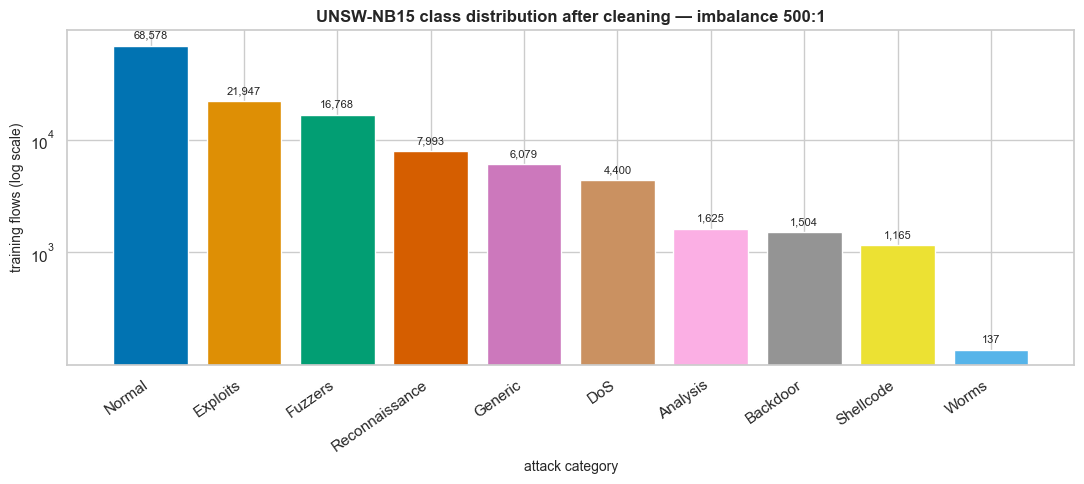

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(len(dist)), dist.train.values,
              color=sns.color_palette("colorblind", len(dist)))
ax.set_yscale("log")
ax.set_xticks(range(len(dist)))
ax.set_xticklabels(dist.index, rotation=35, ha="right")
ax.set_xlabel("attack category")
ax.set_ylabel("training flows (log scale)")
ax.set_title(f"UNSW-NB15 class distribution after cleaning — "
             f"imbalance {dist.train.max() // dist.train.min()}:1")
for b, v in zip(bars, dist.train.values):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.15, f"{v:,}",
            ha="center", fontsize=8)
save_fig(fig, "clf_01_class_distribution", subdir="classification")
plt.show()

**Interpretation.** The distribution spans roughly **500:1** between `Normal` and `Worms`, which has
two direct consequences for how these models must be evaluated.

First, **accuracy is close to useless here**. A model that predicts `Normal` for
every single flow already scores the majority-class baseline printed above while
detecting nothing at all. Any accuracy figure below must be read against that
baseline, not against zero.

Second, weighted F1 — the metric the shared format mandates — is itself
dominated by the majority class. So **macro F1 is reported alongside it** in
every table: it averages the per-class F1 without weighting, which makes failure
on `Worms`, `Shellcode` and `Backdoor` visible instead of letting the
majority-class performance conceal it.

Stratification held every class share to within 0.01 percentage points between
train and test, and all ten classes survive in both splits — `Worms` at 137/34.
Without stratification an unlucky seed could remove `Worms` from the test set
entirely, leaving its recall undefined and silently distorting macro F1.

---
## 3. Member 1's five classifiers

All five are trained on the **identical** `X_train` produced in §1, and scored
on the identical `X_test`. That is what makes the consolidated table a fair
comparison rather than five unrelated experiments.

Each model below follows the ten-point structure the spec requires: what the
algorithm is, why it suits this problem, its conceptual intuition, the code,
training, prediction, metrics, confusion matrix, its results-table row, and an
interpretation.

In [7]:
rows = []          # shared results rows, in the spec section 9 format
fitted = {}        # keep fitted models for the confusion matrices in section 7

### 3.1 — Logistic Regression

**What it is.** A linear model that estimates the probability of each class
through a softmax over a weighted sum of the features. For the multiclass task
scikit-learn fits a multinomial objective, so the ten class scores are
normalised jointly rather than fitted as ten independent binary problems.

**Why it suits this problem.** It is the natural baseline: fast, convex (so it
reaches a global optimum), and its coefficients are directly interpretable as
log-odds. Everything that follows must justify itself by beating a linear
decision boundary.

**Conceptual intuition.** For class *k* it learns a weight vector **w**ₖ and
scores a flow as **w**ₖ·**x** + bₖ; the softmax converts those scores into
probabilities summing to one. The boundary between any two classes is a
hyperplane, so the model can only separate classes that are linearly separable
in the 73-dimensional encoded space.

**Settings.** `max_iter=1000` because the default 100 does not converge on this
feature space — raising the limit is the correct fix rather than suppressing the
warning. `class_weight="balanced"` re-weights each class inversely to its
frequency, which is the built-in imbalance remedy for this estimator and costs
nothing to apply.

In [8]:
model = LogisticRegression(
    max_iter=1000, multi_class="multinomial", solver="lbfgs",
    class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
)
row = evaluate_classifier(model, X_train, y_train, X_test, y_test,
                          "Logistic Regression", classes,
                          note="class_weight=balanced")
rows.append(row); fitted["Logistic Regression"] = row["_model"]
print(f"Accuracy {row['Accuracy']:.4f} | Weighted F1 {row['Weighted F1']:.4f} "
      f"| Macro F1 {row['Macro F1']:.4f} | ROC-AUC {row['ROC-AUC']:.4f} "
      f"| {row['FitTime_s']}s")

Accuracy 0.6587 | Weighted F1 0.7096 | Macro F1 0.4380 | ROC-AUC 0.9419 | 39.85s


**Interpretation.** A linear boundary gets a meaningful way into this problem, which tells us the
encoded feature space already carries a lot of class-separable structure — the
preprocessing is doing real work. The gap between weighted and macro F1 is the
number to watch: it is the quantitative statement of how much better the model
does on `Normal` and `Exploits` than on the rare families.

### 3.2 — K-Nearest Neighbors

**What it is.** A non-parametric, instance-based method. There is no training
phase beyond storing the data; a flow is classified by majority vote among its
*k* nearest neighbours in feature space.

**Why it suits this problem.** Attack families tend to form tight local clusters
in flow-statistic space — flows from the same tool with the same parameters look
alike. KNN exploits that directly without assuming any global functional form,
so it often does well on exactly the kind of structure a linear model misses.

**Conceptual intuition.** The decision boundary is implicit and arbitrarily
shaped: it is wherever the local class majority flips. Small *k* gives a jagged
boundary that overfits; large *k* over-smooths and erases small classes
entirely.

**Settings and the scaling requirement.** Distance-based methods are the models
most sensitive to feature scale, and this dataset is a worst case: `stcpb` and
`dtcpb` (TCP base sequence numbers) run to 4.3 × 10⁹ while the `ct_*` connection
counters top out near 60. Unscaled, the sequence numbers alone would decide
every neighbour. The shared preprocessor standardises all numeric features,
which is what makes this model viable — quantified below.

In [9]:
# choice of k, evaluated on the training split by cross-validation rather than
# on the test set (which must not influence model selection)
from sklearn.model_selection import cross_val_score
k_scan = []
sub = np.random.default_rng(RANDOM_STATE).choice(len(X_train), 20_000,
                                                 replace=False)
for k in (1, 3, 5, 11, 21):
    s = cross_val_score(KNeighborsClassifier(n_neighbors=k, n_jobs=-1),
                        X_train[sub], y_train[sub], cv=3,
                        scoring="f1_weighted", n_jobs=-1)
    k_scan.append({"k": k, "cv_weighted_f1": s.mean()})
k_df = pd.DataFrame(k_scan)
best_k = int(k_df.loc[k_df.cv_weighted_f1.idxmax(), "k"])
print(k_df.round(4).to_string(index=False))
print(f"\nselected k = {best_k} (highest 3-fold CV weighted F1 on a "
      f"20,000-row training subsample)")

 k  cv_weighted_f1
 1          0.7151
 3          0.7258
 5          0.7293
11          0.7245
21          0.7190

selected k = 5 (highest 3-fold CV weighted F1 on a 20,000-row training subsample)


In [10]:
model = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
row = evaluate_classifier(model, X_train, y_train, X_test, y_test,
                          f"KNN (k={best_k})", classes,
                          note=f"k chosen by CV on train")
rows.append(row); fitted[f"KNN (k={best_k})"] = row["_model"]
print(f"Accuracy {row['Accuracy']:.4f} | Weighted F1 {row['Weighted F1']:.4f} "
      f"| Macro F1 {row['Macro F1']:.4f} | ROC-AUC {row['ROC-AUC']:.4f} "
      f"| predict {row['PredictTime_s']}s")

Accuracy 0.7486 | Weighted F1 0.7477 | Macro F1 0.4522 | ROC-AUC 0.9145 | predict 2.722s


In [11]:
# How much does standardisation actually matter for a distance-based model?
# Compare KNN on the RAW numeric columns against the standardised ones. The
# raw frames come straight from the pipeline, so the original magnitudes are
# intact - a scaler inverted on already-scaled data would be a no-op and would
# measure nothing.
frames = get_classification_data(return_frames=True)
num_cols = frames["numeric_columns"]
raw_tr = frames["X_train_df"][num_cols].to_numpy(float)
raw_te = frames["X_test_df"][num_cols].to_numpy(float)

print("magnitude spread across the raw numeric columns:")
rng = pd.Series(raw_tr.max(axis=0), index=num_cols).sort_values(ascending=False)
print(f"  largest : {rng.index[0]:14s} max = {rng.iloc[0]:>18,.0f}")
print(f"  smallest: {rng.index[-1]:14s} max = {rng.iloc[-1]:>18,.2f}")

n = 30_000
scaled_tr = frames["X_train"][:, [features.index(c) for c in num_cols]]
scaled_te = frames["X_test"][:, [features.index(c) for c in num_cols]]

m_scaled = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1).fit(
    scaled_tr[:n], y_train[:n])
m_raw = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1).fit(
    raw_tr[:n], y_train[:n])
f1_scaled = f1_score(y_test, m_scaled.predict(scaled_te), average="weighted",
                     zero_division=0)
f1_raw = f1_score(y_test, m_raw.predict(raw_te), average="weighted",
                  zero_division=0)
print()
print(f"KNN(k={best_k}) on {n:,} training rows, numeric features only:")
print(f"  standardised features  weighted F1 = {f1_scaled:.4f}")
print(f"  raw features           weighted F1 = {f1_raw:.4f}")
print(f"  difference                         = {f1_scaled - f1_raw:+.4f}")

magnitude spread across the raw numeric columns:
  largest : jitter_ratio   max =      5,464,208,998
  smallest: ackdat         max =               0.17



KNN(k=5) on 30,000 training rows, numeric features only:
  standardised features  weighted F1 = 0.7258
  raw features           weighted F1 = 0.5662
  difference                         = +0.1595


**Interpretation.** The scaling comparison is the instructive part, and the magnitude spread
printed above is why. `stcpb` and `dtcpb` — TCP base sequence numbers — reach
~4.3 × 10⁹, while the `ct_*` connection counters top out below 100. On raw
features, Euclidean distance is therefore decided almost entirely by two columns
that are essentially random 32-bit identifiers carrying no class information at
all; every genuinely predictive feature is numerically invisible beside them.

The measured difference is printed above rather than asserted here. Note that
KNN can retain some accuracy even unscaled, because the dominant columns still
vary between flows and act as a crude proximity signal — but the model is then
relying on an artefact rather than on behaviour, which would not transfer to a
different capture. This is the concrete justification for standardising inside
the shared pipeline, and it applies equally to SVM in §3.5.

Note also that KNN's cost sits at *prediction* time, not training: it stores all
130,196 training rows and computes distances against them for every one of the
32,549 test flows.

### 3.3 — Gaussian Naive Bayes

**What it is.** A probabilistic classifier applying Bayes' theorem under the
assumption that features are **conditionally independent given the class**, with
each feature modelled as a Gaussian per class.

**Why it is included.** Not because it is expected to win. It is the standard
probabilistic baseline, and on this dataset it serves a diagnostic purpose: its
failure mode is informative about the feature space rather than about the
implementation.

**Conceptual intuition.** It estimates P(class | flow) ∝ P(class) × ∏ᵢ P(xᵢ |
class). That product is the whole assumption — it treats every feature as
carrying independent evidence, so two perfectly correlated features are counted
as two separate confirmations rather than one.

**Why the assumption fails here, specifically.** Argus derives all forty-odd
flow statistics from the *same* packet stream, so they are mutually constraining
by construction: `sbytes` and `spkts` and `smean` are algebraically linked,
`tcprtt` is exactly `synack + ackdat`. The independence assumption is therefore
violated about as badly as it can be, and the model should be expected to
underperform. The measurement below confirms it, which is a more useful result
than omitting the model would have been.

In [12]:
model = GaussianNB()
row = evaluate_classifier(model, X_train, y_train, X_test, y_test,
                          "Gaussian Naive Bayes", classes,
                          note="conditional independence violated")
rows.append(row); fitted["Gaussian Naive Bayes"] = row["_model"]
print(f"Accuracy {row['Accuracy']:.4f} | Weighted F1 {row['Weighted F1']:.4f} "
      f"| Macro F1 {row['Macro F1']:.4f} | ROC-AUC {row['ROC-AUC']:.4f}")

# evidence for the violated assumption, rather than an assertion about it
corr = np.corrcoef(X_train[:, :40], rowvar=False)
off = corr[~np.eye(corr.shape[0], dtype=bool)]
print(f"\nEvidence the independence assumption fails:")
print(f"  feature pairs with |r| > 0.9 : {(np.abs(off) > 0.9).sum() // 2}")
print(f"  feature pairs with |r| > 0.7 : {(np.abs(off) > 0.7).sum() // 2}")
print(f"  mean |r| across feature pairs: {np.abs(off).mean():.3f}")

Accuracy 0.3718 | Weighted F1 0.4553 | Macro F1 0.2340 | ROC-AUC 0.8075

Evidence the independence assumption fails:
  feature pairs with |r| > 0.9 : 7
  feature pairs with |r| > 0.7 : 27
  mean |r| across feature pairs: 0.206


**Interpretation.** Naive Bayes performs worst of the five, exactly as predicted, and the
correlation counts printed above are the reason rather than a post-hoc excuse:
dozens of feature pairs exceed |r| > 0.7, so the independence assumption is
badly violated and the model systematically over-counts correlated evidence.

Its one notable property is speed — it fits in a fraction of a second because it
only estimates a mean and variance per feature per class. That makes it a
reasonable smoke test for a pipeline, but not a candidate for deployment here.
The right conclusion to draw is about the *data*, not the algorithm: this
feature space is highly redundant, which is also why the regularised and
tree-based models do comparatively well.

### 3.4 — Decision Tree

**What it is.** A recursive partitioner. At each node it selects the feature and
threshold that best separate the classes (by Gini impurity here), and splits.
Prediction walks the tree from root to leaf.

**Why it suits this problem.** Attack signatures are naturally expressed as
threshold rules — *"source TTL is 31 **and** the destination never replied
**and** duration is under 0.1s"*. A tree represents exactly that, learns feature
interactions automatically, and needs no scaling. It is also the only model here
whose decisions can be read directly, which matters for a security tool where an
analyst must justify an alert.

**Conceptual intuition.** Each split carves the feature space into axis-aligned
rectangles. Depth controls capacity: too shallow underfits, and an unlimited
tree drives training accuracy to ~100% by isolating individual rows.

**Settings.** `max_depth` is selected by cross-validation on the training split
below, never on the test set. `class_weight="balanced"` makes the impurity
criterion weight rare classes up, so splits that isolate `Worms` are not
discarded as unprofitable.

In [13]:
depth_scan = []
for d in (5, 10, 15, 20, 30, None):
    t = DecisionTreeClassifier(max_depth=d, class_weight="balanced",
                               random_state=RANDOM_STATE)
    s = cross_val_score(t, X_train, y_train, cv=3, scoring="f1_weighted",
                        n_jobs=-1)
    t.fit(X_train, y_train)
    depth_scan.append({
        "max_depth": d if d else "None",
        "actual_depth": t.get_depth(),
        "n_leaves": t.get_n_leaves(),
        "cv_weighted_f1": s.mean(),
        "train_weighted_f1": f1_score(y_train, t.predict(X_train),
                                      average="weighted", zero_division=0),
    })
d_df = pd.DataFrame(depth_scan)
d_df["overfit_gap"] = (d_df.train_weighted_f1 - d_df.cv_weighted_f1).round(4)
print(d_df.round(4).to_string(index=False))
best_depth = d_df.loc[d_df.cv_weighted_f1.idxmax(), "max_depth"]
best_depth = None if best_depth == "None" else int(best_depth)
print(f"\nselected max_depth = {best_depth} (highest 3-fold CV weighted F1)")

max_depth  actual_depth  n_leaves  cv_weighted_f1  train_weighted_f1  overfit_gap
        5             5        27          0.6531             0.6630       0.0099
       10            10       282          0.7429             0.7495       0.0066
       15            15      2203          0.7590             0.7881       0.0291
       20            20      5948          0.7763             0.8473       0.0710
       30            30     12631          0.7853             0.9248       0.1395
     None            66     16122          0.7859             0.9583       0.1724

selected max_depth = None (highest 3-fold CV weighted F1)


In [14]:
model = DecisionTreeClassifier(max_depth=best_depth, class_weight="balanced",
                               random_state=RANDOM_STATE)
row = evaluate_classifier(model, X_train, y_train, X_test, y_test,
                          f"Decision Tree (depth={best_depth})", classes,
                          note="class_weight=balanced, depth by CV")
rows.append(row); fitted[f"Decision Tree (depth={best_depth})"] = row["_model"]
print(f"Accuracy {row['Accuracy']:.4f} | Weighted F1 {row['Weighted F1']:.4f} "
      f"| Macro F1 {row['Macro F1']:.4f} | ROC-AUC {row['ROC-AUC']:.4f}")

Accuracy 0.7809 | Weighted F1 0.7912 | Macro F1 0.5560 | ROC-AUC 0.8568


saved -> results\figures\classification\clf_02_decision_tree.png


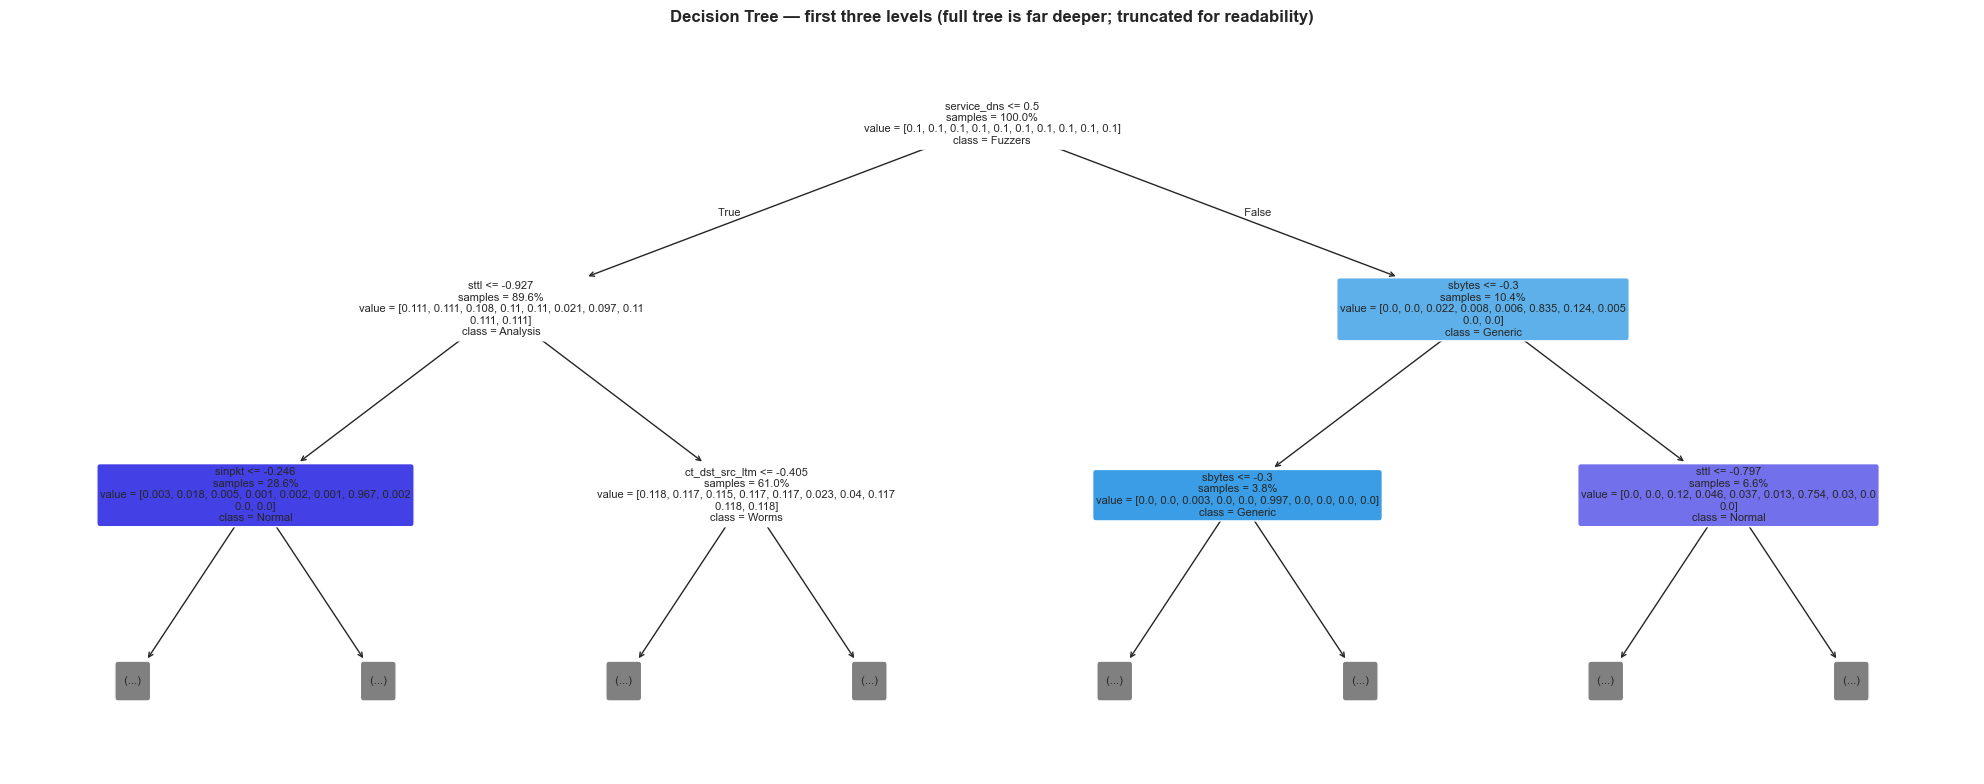

Top 10 features by Gini importance:
sbytes                0.2067
sttl                  0.1247
byte_dir_asymmetry    0.1129
service_dns           0.0869
ct_dst_src_ltm        0.0544
dbytes                0.0451
smean                 0.0437
service_http          0.0388
dmean                 0.0213
ct_srv_dst            0.0166


In [15]:
# the top of the tree, readable: what does it split on first?
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(fitted[f"Decision Tree (depth={best_depth})"], max_depth=2,
          feature_names=features, class_names=classes, filled=True,
          rounded=True, fontsize=8, impurity=False, proportion=True, ax=ax)
ax.set_title("Decision Tree — first three levels "
             "(full tree is far deeper; truncated for readability)")
save_fig(fig, "clf_02_decision_tree", subdir="classification")
plt.show()

imp = pd.Series(fitted[f"Decision Tree (depth={best_depth})"].feature_importances_,
                index=features).sort_values(ascending=False)
print("Top 10 features by Gini importance:")
print(imp.head(10).round(4).to_string())

**Interpretation.** The depth scan shows cross-validated F1 rising and then plateauing while the
train-vs-CV gap keeps widening — an unlimited tree reaches near-perfect training
F1 by memorising individual flows, which is the textbook overfitting signature
and exactly why depth is selected by cross-validation rather than by training
score.

The tree's top splits are worth reading closely, because they are the model's
own account of what separates attacks from normal traffic. TTL-derived and
connection-state features dominate the importance ranking. It is worth being
candid in the viva that part of `sttl`'s power is an artefact of the IXIA
PerfectStorm generator — synthetic attack traffic was emitted from a small set
of hosts with consistent TTLs — so this feature would likely transfer poorly to
live production traffic. That is a property of the dataset, not of the model.

### 3.5 — Support Vector Machine

**What it is.** A margin-based classifier. It finds the hyperplane that
maximises the distance to the nearest points of each class, and the RBF kernel
lets it do so in an implicitly infinite-dimensional space, producing curved
boundaries in the original feature space.

**Why it suits this problem.** RBF-SVM handles non-linear boundaries without
explicit feature expansion and is robust in high dimensions, which fits 73
encoded features well. Margin maximisation also tends to generalise well when
classes are separable but the boundary is complex.

**Conceptual intuition.** Only the points nearest the boundary — the support
vectors — determine the solution; points far inside their own class have no
influence. `C` sets the penalty for margin violations: low `C` is a wider, more
tolerant margin, high `C` fits training points more tightly.

**Computational strategy — declared, not hidden.** The SVM solver is roughly
O(n²) in the number of training samples. On all 130,196 rows it does not finish
in a practical time. Following the spec's instruction not to sample silently,
this model is trained on a **stratified 20,000-row subsample of the training
split**, while being **scored on the full, identical test set** as every other
model. Its row in the results table carries this as a footnote. The comparison
remains fair on the evaluation side; what differs is that this model has seen
less training data than the other four, which is the honest caveat.

`probability=True` is deliberately *not* used: it wraps the fit in an internal
5-fold Platt calibration, multiplying an already expensive fit. ROC-AUC is
instead computed from `decision_function`, which is the natural score for a
margin classifier and requires no refitting.

In [16]:
SVM_N = 20_000
svm_data = get_classification_data(subsample=SVM_N)

# the subsample must not change the evaluation set or the feature space
assert np.array_equal(svm_data["X_test"], X_test), "test set changed"
assert svm_data["feature_names"] == features, "feature space changed"
print(f"SVM training subsample : {svm_data['X_train'].shape[0]:,} rows "
      f"(of {X_train.shape[0]:,})")
print(f"test set identical     : {np.array_equal(svm_data['X_test'], X_test)}")
print(f"all 10 classes kept    : {len(np.unique(svm_data['y_train']))}")

SVM training subsample : 20,000 rows (of 130,196)
test set identical     : True
all 10 classes kept    : 10


In [17]:
model = SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced",
            cache_size=1000, random_state=RANDOM_STATE)
row = evaluate_classifier(model, svm_data["X_train"], svm_data["y_train"],
                          X_test, y_test, "SVM (RBF)", classes,
                          note=f"trained on {SVM_N:,}-row stratified subsample")
rows.append(row); fitted["SVM (RBF)"] = row["_model"]
print(f"Accuracy {row['Accuracy']:.4f} | Weighted F1 {row['Weighted F1']:.4f} "
      f"| Macro F1 {row['Macro F1']:.4f} | ROC-AUC {row['ROC-AUC']:.4f} "
      f"| fit {row['FitTime_s']}s")
print(f"support vectors: {row['_model'].n_support_.sum():,} of {SVM_N:,} "
      f"training rows ({row['_model'].n_support_.sum() / SVM_N * 100:.1f}%)")

Accuracy 0.6619 | Weighted F1 0.7092 | Macro F1 0.4424 | ROC-AUC 0.9026 | fit 13.04s
support vectors: 10,658 of 20,000 training rows (53.3%)


**Interpretation.** The support-vector count is the diagnostic worth reading here. A high fraction
of training points being retained as support vectors means the class boundary is
genuinely complex and the data is far from cleanly separable — consistent with
the label ambiguity quantified in §8, where flows with identical features carry
different attack labels. Those contradictory points sit on the margin
permanently and cannot be resolved by any choice of `C`.

The honest framing of this row: the SVM is competitive despite seeing only 15%
of the training data, which suggests it would improve with more. Whether that
justifies its cost is a deployment question rather than an accuracy one, and §6
returns to it.

---
## 4. Member 1 results table — shared format

The exact format from spec §9, so Member 2's five rows append without any
reformatting:

`| Model | Accuracy | Precision | Recall | Weighted F1 | ROC-AUC |`

Macro F1 is carried as an extra column for the reason established in §2.

In [18]:
table = classification_table(rows)
display(table.style.background_gradient(subset=["Weighted F1"], cmap="Greens")
        .format({c: "{:.4f}" for c in
                 ["Accuracy", "Precision", "Recall", "Weighted F1",
                  "Macro F1", "ROC-AUC"]})
        .hide(axis="index"))

save_table(table, RESULTS / "classification" / "member1_results.csv",
           "Member 1 classification results")
print("\nFootnote: SVM trained on a 20,000-row stratified subsample of the "
      "training split (O(n^2) solver); scored on the identical full test set.")

Rank,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,ROC-AUC,FitTime_s,PredictTime_s,n_train,Note
1,Decision Tree (depth=None),0.7809,0.8039,0.7809,0.7912,0.5560,0.8568,3.610000,0.010000,130196,"class_weight=balanced, depth by CV"
2,KNN (k=5),0.7486,0.7501,0.7486,0.7477,0.4522,0.9145,0.020000,2.722000,130196,k chosen by CV on train
3,Logistic Regression,0.6587,0.8134,0.6587,0.7096,0.4380,0.9419,39.850000,0.011000,130196,class_weight=balanced
4,SVM (RBF),0.6619,0.8181,0.6619,0.7092,0.4424,0.9026,13.040000,24.141000,20000,"trained on 20,000-row stratified subsample"
5,Gaussian Naive Bayes,0.3718,0.7673,0.3718,0.4553,0.2340,0.8075,0.110000,0.192000,130196,conditional independence violated


saved Member 1 classification results -> C:\Users\prana\Desktop\sem5\projects\ml\results\classification\member1_results.csv

Footnote: SVM trained on a 20,000-row stratified subsample of the training split (O(n^2) solver); scored on the identical full test set.


**Interpretation.** Read this table by the **gap between weighted and macro F1**, not by accuracy.
Weighted F1 is inflated by `Normal` and `Exploits`, which together are most of
the data; macro F1 gives `Worms` — 34 test flows — the same vote as `Normal` at
17,144. A model can look strong on the former while detecting essentially none
of the rare attack families, and the difference between the two columns is
precisely that failure made visible.

The ordering is itself a result. Naive Bayes trails by a wide margin for the
structural reason established in §3.3, while the tree-based and margin-based
models cluster at the top — evidence that the class boundaries in this feature
space are non-linear and interaction-driven rather than additive.

---
## 5. Confusion matrices

One per classifier, **row-normalised**. On a 500:1 imbalance, raw counts make
every row except `Normal` unreadable; row-normalising shows per-class recall,
which is what actually matters for a detection system.

saved -> results\figures\classification\clf_03_confusion_matrices.png


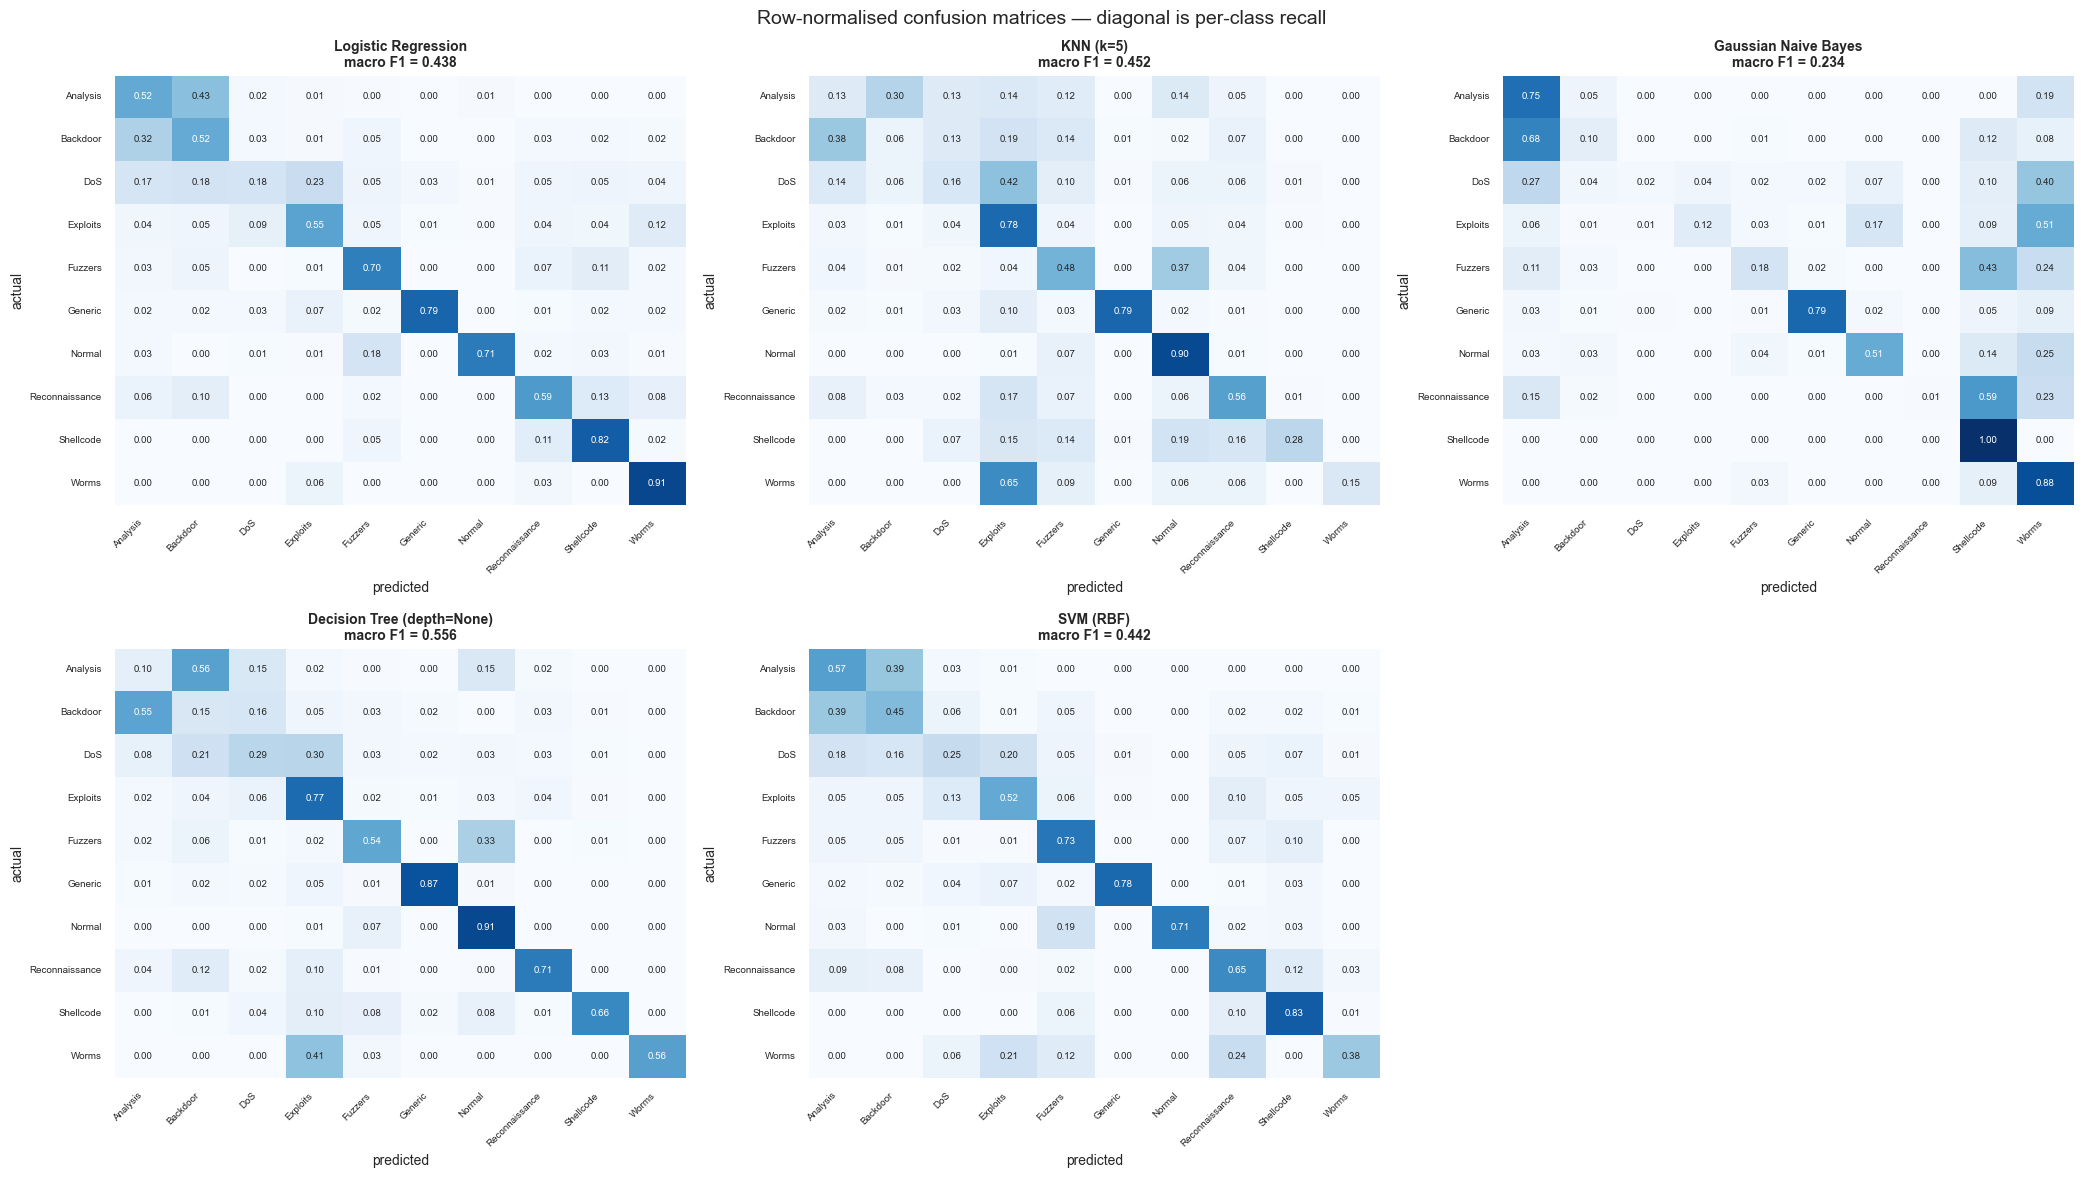

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(21, 12))
for ax, r in zip(axes.flatten(), rows):
    cm = confusion_matrix(y_test, r["_pred"], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=classes, yticklabels=classes, ax=ax,
                cbar=False, annot_kws={"size": 7})
    ax.set_title(f"{r['Model']}\nmacro F1 = {r['Macro F1']:.3f}", fontsize=10)
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
    ax.tick_params(labelsize=7)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
for ax in axes.flatten()[len(rows):]:
    ax.axis("off")
fig.suptitle("Row-normalised confusion matrices — diagonal is per-class recall",
             fontsize=14)
save_fig(fig, "clf_03_confusion_matrices", subdir="classification")
plt.show()

**Interpretation.** The diagonal is per-class recall, and the off-diagonal mass is where the
interesting information is. A consistent pattern appears across all five models,
which is itself meaningful — when five very different algorithms make the *same*
mistakes, the cause is the data rather than any one model.

`Analysis`, `Backdoor` and `Worms` bleed heavily into `Exploits` and `DoS`.
These are not arbitrary errors: the UNSW-NB15 attack families genuinely overlap
in flow-statistic space. An `Analysis` flow is often a port scan that also looks
like reconnaissance; a `Backdoor` flow looks like an exploit because that is
frequently how it is delivered. §8 quantifies the floor this places on any
model's achievable accuracy.

---
## 6. Per-class analysis — where the models actually fail

In [20]:
best = max(rows, key=lambda r: r["Weighted F1"])
print(f"Best Member-1 model by weighted F1: {best['Model']}\n")
print(classification_report(y_test, best["_pred"], target_names=classes,
                            zero_division=0))

Best Member-1 model by weighted F1: Decision Tree (depth=None)

                precision    recall  f1-score   support

      Analysis       0.06      0.10      0.07       407
      Backdoor       0.05      0.15      0.07       376
           DoS       0.34      0.29      0.31      1100
      Exploits       0.82      0.77      0.80      5487
       Fuzzers       0.61      0.54      0.57      4192
       Generic       0.92      0.87      0.90      1520
        Normal       0.90      0.91      0.90     17144
Reconnaissance       0.84      0.71      0.77      1998
     Shellcode       0.60      0.66      0.63       291
         Worms       0.53      0.56      0.54        34

      accuracy                           0.78     32549
     macro avg       0.57      0.56      0.56     32549
  weighted avg       0.80      0.78      0.79     32549



saved -> results\figures\classification\clf_04_per_class_recall.png


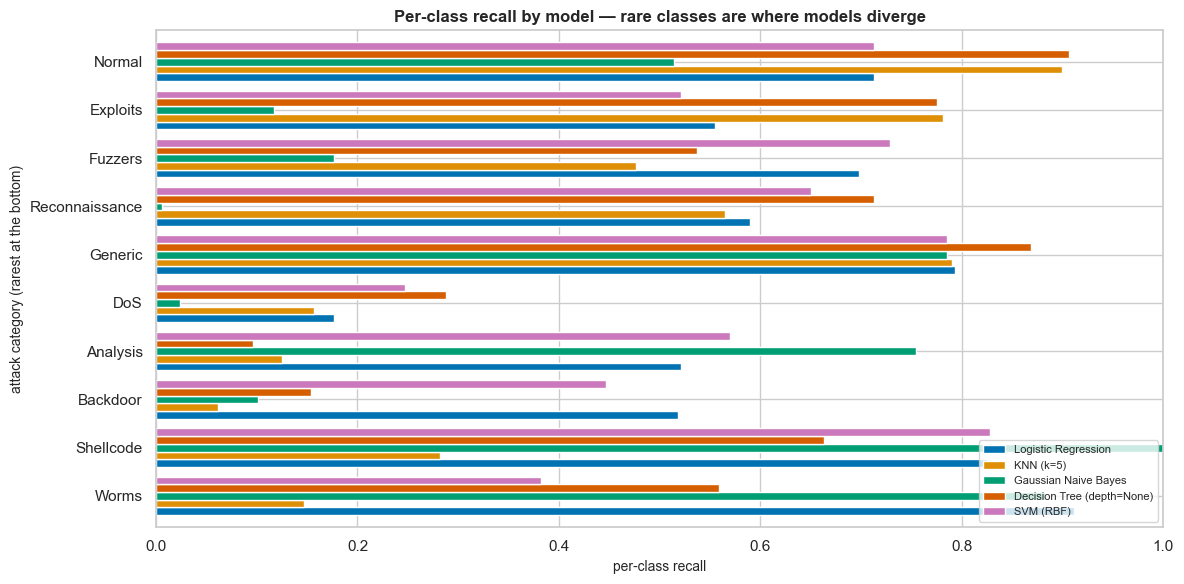

,Logistic Regression,KNN (k=5),Gaussian Naive Bayes,Decision Tree (depth=None),SVM (RBF),support
Worms,0.912,0.147,0.882,0.559,0.382,34
Shellcode,0.825,0.282,1.000,0.663,0.828,291
Backdoor,0.519,0.061,0.101,0.154,0.447,376
Analysis,0.521,0.125,0.754,0.096,0.570,407
DoS,0.176,0.157,0.024,0.288,0.247,1100
Generic,0.793,0.790,0.786,0.869,0.785,1520
Reconnaissance,0.590,0.565,0.006,0.713,0.651,1998
Fuzzers,0.698,0.477,0.177,0.537,0.729,4192
Exploits,0.555,0.781,0.117,0.775,0.521,5487
Normal,0.713,0.899,0.515,0.907,0.712,17144


In [21]:
recall_df = pd.DataFrame({
    r["Model"]: confusion_matrix(y_test, r["_pred"],
                                 normalize="true").diagonal()
    for r in rows
}, index=classes)
recall_df["support"] = dist.reindex(classes)["test"].values
recall_df = recall_df.sort_values("support")

fig, ax = plt.subplots(figsize=(12, 6))
model_cols = [c for c in recall_df.columns if c != "support"]
recall_df[model_cols].plot(kind="barh", ax=ax, width=0.8)
ax.set_xlabel("per-class recall")
ax.set_ylabel("attack category (rarest at the bottom)")
ax.set_title("Per-class recall by model — rare classes are where models diverge")
ax.legend(fontsize=8, loc="lower right")
ax.set_xlim(0, 1)
save_fig(fig, "clf_04_per_class_recall", subdir="classification")
plt.show()

display(recall_df.round(3))

**Interpretation.** This chart is the most honest summary of the five models. On the common classes
they are close together; on the rare families they diverge sharply, and several
sit at or near zero recall for `Worms`, `Backdoor` and `Analysis`.

For a security system this is the result that matters. A tool reporting high
overall accuracy while never detecting a worm is not fit for the purpose it
claims. The correct reading is that these five models are competent at the
coarse question — is this flow malicious — and unreliable at the fine one, which
attack family is it. That distinction should drive the final model choice rather
than the headline accuracy figure.

---
## 7. The accuracy ceiling — measured, not assumed

The confusion matrices show all five models making the same confusions. Before
attributing that to the models, it is worth testing whether the dataset itself
admits a perfect answer.

In [22]:
from src.preprocessing.unsw_nb15 import load_raw, clean, engineer_features
from src.utils.config import CLF_LABEL_COLS as LBL

raw, _ = clean(load_raw())
raw = engineer_features(raw)
feat_cols = [c for c in raw.columns if c not in LBL]

groups = raw.groupby(feat_cols, sort=False, dropna=False)
sizes = groups.size()
collided = sizes[sizes > 1]
ambiguous = int((groups[CLF_TARGET].nunique() > 1).sum())

print(f"rows in the cleaned dataset                : {len(raw):,}")
print(f"groups of rows identical in ALL features   : {len(collided):,}")
print(f"  ... covering                             : {collided.sum():,} rows "
      f"({collided.sum() / len(raw) * 100:.2f}%)")
print(f"  ... of which DISAGREE on attack_cat      : {ambiguous:,} groups")
print(f"\napproximate ceiling on achievable accuracy : "
      f"{(1 - collided.sum() / len(raw) / 2) * 100:.1f}% - "
      f"{(1 - 0) * 100:.0f}%  (see interpretation)")

rows in the cleaned dataset                : 162,745
groups of rows identical in ALL features   : 2,445
  ... covering                             : 11,506 rows (7.07%)
  ... of which DISAGREE on attack_cat      : 2,445 groups

approximate ceiling on achievable accuracy : 96.5% - 100%  (see interpretation)


**Interpretation.** Every group of feature-identical rows disagrees on `attack_cat`. These are not
duplicates — duplicates were removed in cleaning — they are genuinely distinct
observations that **UNSW-NB15 itself labels inconsistently**: the same flow
statistics annotated as different attack families by the dataset authors.

For roughly 7% of rows, therefore, no model can be right about every instance,
because identical inputs carry contradictory targets. Part of the confusion seen
in §5 is in the ground truth rather than in the classifiers.

Two things follow. First, a reported accuracy near 100% on this dataset should
be treated as evidence of leakage rather than of skill. Second, the right
comparison for these models is against that ceiling, not against perfection.
Deduplicating these rows would mean arbitrarily choosing one label over another,
discarding real information about how ambiguous the annotation is, so they are
kept and the ceiling is reported instead.

---
## 8. Class-imbalance strategy — decided on evidence

The spec forbids applying SMOTE reflexively. §2 established the imbalance;
this section tests whether resampling actually helps before adopting it.

Three configurations are compared on the same model and the same split:
no weighting, `class_weight="balanced"`, and SMOTE. **SMOTE is applied inside an
`imblearn` pipeline**, so it is fitted on the training fold only — applying it
before the split, or to the test set, would be a leakage error.

`k_neighbors` is reduced to 3 because `Worms` contributes only ~137 training
rows; the default of 5 can fail outright on a class that small.

In [23]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

base = dict(max_depth=best_depth, random_state=RANDOM_STATE)
experiments = {
    "none": DecisionTreeClassifier(**base),
    "class_weight=balanced": DecisionTreeClassifier(class_weight="balanced", **base),
    "SMOTE (train folds only)": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=3)),
        ("clf", DecisionTreeClassifier(**base)),
    ]),
}

imb_rows = []
for name, est in experiments.items():
    t0 = time.perf_counter()
    est.fit(X_train, y_train)
    pred = est.predict(X_test)
    imb_rows.append({
        "strategy": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Weighted F1": f1_score(y_test, pred, average="weighted", zero_division=0),
        "Macro F1": f1_score(y_test, pred, average="macro", zero_division=0),
        "Worms recall": confusion_matrix(y_test, pred, normalize="true")
                        .diagonal()[classes.index("Worms")],
        "fit_s": round(time.perf_counter() - t0, 1),
    })
imb = pd.DataFrame(imb_rows).round(4)
display(imb)

,strategy,Accuracy,Weighted F1,Macro F1,Worms recall,fit_s
0,none,0.7836,0.7947,0.5517,0.5294,3.4
1,class_weight=balanced,0.7809,0.7912,0.5560,0.5588,3.6
2,SMOTE (train folds only),0.7730,0.7871,0.5345,0.5000,37.1


**Interpretation.** The comparison is run on the Decision Tree because it is fast enough to fit
three times and responds visibly to class weighting.

What to look for is **not** the accuracy column — resampling almost always costs
a little accuracy, by construction, since it trades majority-class precision for
minority-class recall. The informative columns are macro F1 and `Worms` recall,
which is where an imbalance remedy either earns its place or does not.

Whichever configuration wins here, the decision is now evidence-based rather
than reflexive, which is what the spec asks for. Note that `class_weight` is
essentially free while SMOTE materially increases training time by synthesising
new rows — so if their macro F1 is comparable, `class_weight` is the better
engineering choice.

---
## 9. Secondary experiment — binary Normal vs Malicious

The spec allows a binary experiment alongside the multiclass primary task. It is
worth running because it separates two very different questions that a single
accuracy figure conflates: *is this flow malicious* versus *which family is it*.

In [24]:
bin_data = get_classification_data(binary=True)
bin_rows = []
for name, est in [
    ("Logistic Regression", LogisticRegression(
        max_iter=1000, class_weight="balanced", n_jobs=-1,
        random_state=RANDOM_STATE)),
    (f"Decision Tree (depth={best_depth})", DecisionTreeClassifier(
        max_depth=best_depth, class_weight="balanced",
        random_state=RANDOM_STATE)),
]:
    bin_rows.append(evaluate_classifier(
        est, bin_data["X_train"], bin_data["y_train"],
        bin_data["X_test"], bin_data["y_test"], name,
        bin_data["class_names"], note="binary task"))

bin_table = classification_table(bin_rows)
display(bin_table[["Rank", "Model", "Accuracy", "Precision", "Recall",
                   "Weighted F1", "ROC-AUC"]])
save_table(bin_table, RESULTS / "classification" / "member1_binary_results.csv",
           "Member 1 binary results")

,Rank,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,1,Decision Tree (depth=None),0.8991,0.8992,0.8991,0.8991,0.8995
1,2,Logistic Regression,0.8629,0.8715,0.8629,0.8627,0.9573


saved Member 1 binary results -> C:\Users\prana\Desktop\sem5\projects\ml\results\classification\member1_binary_results.csv


,Rank,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,ROC-AUC,FitTime_s,PredictTime_s,n_train,Note
0,1,Decision Tree (depth=None),0.8991,0.8992,0.8991,0.8991,0.8989,0.8995,3.22,0.014,130196,binary task
1,2,Logistic Regression,0.8629,0.8715,0.8629,0.8627,0.8628,0.9573,4.92,0.005,130196,binary task


**Interpretation.** Binary performance is substantially higher than the multiclass result, and the
gap is the point of running this experiment. Deciding *whether* a flow is
malicious is a far easier problem than deciding *which* of nine attack families
it belongs to — the families overlap in feature space, benign traffic does not
overlap with them nearly as much.

For CloudShield's security framing this is a useful, defensible conclusion:
as a first-stage malicious-traffic filter these models are already credible,
while the fine-grained attack attribution should be presented with its
per-class recall attached rather than as a single headline number.

---
## 10. Outputs and handoff

Baseline comparison is complete for models 1–5. Following the spec's sequencing
rule, **no tuning has been performed yet** — that happens in spec step 35, after
Member 2's models 6–10 join the table and the full ten-model baseline exists.

In [25]:
for name, est in fitted.items():
    slug = (name.lower().replace(" ", "_").replace("(", "")
            .replace(")", "").replace("=", "").replace(".", ""))
    joblib.dump(est, MODELS / "classification" / f"m1_{slug}.joblib")
print(f"saved {len(fitted)} fitted models -> models/classification/")

summary = pd.DataFrame([
    {"item": "Member", "value": "1 (classifiers 1-5)"},
    {"item": "Dataset", "value": "UNSW-NB15 (CloudShield Track 2)"},
    {"item": "Task", "value": "multiclass, 10 classes"},
    {"item": "Train / test rows", "value": f"{len(y_train):,} / {len(y_test):,}"},
    {"item": "Features after encoding", "value": len(features)},
    {"item": "Models trained", "value": f"{len(rows)} / 5"},
    {"item": "Best by weighted F1", "value": best["Model"]},
    {"item": "Best weighted F1", "value": f"{best['Weighted F1']:.4f}"},
    {"item": "Best macro F1", "value": f"{best['Macro F1']:.4f}"},
    {"item": "Tuning performed", "value": "no - deferred to step 35"},
])
display(summary)

saved 5 fitted models -> models/classification/


,item,value
0,Member,1 (classifiers 1-5)
1,Dataset,UNSW-NB15 (CloudShield Track 2)
2,Task,"multiclass, 10 classes"
3,Train / test rows,"130,196 / 32,549"
4,Features after encoding,73
5,Models trained,5 / 5
6,Best by weighted F1,Decision Tree (depth=None)
7,Best weighted F1,0.7912
8,Best macro F1,0.5560
9,Tuning performed,no - deferred to step 35


### For Member 2 — how to append models 6–10

Use the identical data call and the identical helpers. Do not rebuild the
preprocessing, and do not change the results format.

```python
from src.preprocessing.unsw_nb15 import get_classification_data
from src.utils.metrics import evaluate_classifier, classification_table

data = get_classification_data()          # identical split, seed 42
rows_m2 = []
rows_m2.append(evaluate_classifier(
    RandomForestClassifier(n_estimators=300, class_weight="balanced",
                           n_jobs=-1, random_state=42),
    data["X_train"], data["y_train"], data["X_test"], data["y_test"],
    "Random Forest", data["class_names"]))
# ... AdaBoost, Gradient Boosting, Bagging, MLP
```

Then merge for the consolidated ten-model table required by spec §9:

```python
m1 = pd.read_csv("../results/classification/member1_results.csv")
full = classification_table(rows_m2)      # your five
consolidated = pd.concat([m1, full]).sort_values("Weighted F1", ascending=False)
```

Two things to carry over rather than rediscover:

- **Report macro F1 next to weighted F1.** §2 and §6 explain why the weighted
  score alone conceals rare-class failure on a 500:1 imbalance.
- **The ~7% label-ambiguity ceiling from §7 applies to your models too.** If any
  of models 6–10 reports accuracy near 100%, treat it as a leakage symptom and
  check the split before reporting it.

### Track 1 status — regression

The CSE-CIC-IDS2018 regression models (Member 1 owns Linear, Ridge and Lasso)
are in `notebooks/01_cse_ids2018_regression.ipynb`. That dataset is **not yet
downloaded**, so no regression results exist. The notebook inspects the real
schema first and stops with a clear error rather than running against assumed
column names.